#  Predicting Dinosaur Diet from Physical Characteristics
### Data Mining Project | April 2026
#### Name: Laxmi Narayana Gugulothu
#### ID: 24180164
## Project Overview

---

**Science Question:**
> *Can we accurately predict a dinosaur's dietary category (carnivore, herbivore, omnivore) based on its physical type, body size, geological period, and geographic location?*

**Why it matters:** When direct dietary fossil evidence (tooth marks, gut contents, coprolites) is unavailable, a reliable classifier lets palaeontologists make data-driven dietary estimates from routinely recorded attributes alone.

---

### Data Mining Tasks Performed
| Task | Description |
|------|-------------|
| **Data Cleaning** | Fix malformed rows, parse numeric fields, impute missing values |
| **Feature Engineering** | Extract geological era, sub-period, age (Mya), and continent from raw text fields |
| **Exploratory Data Analysis (EDA)** | Distribution plots, cross-tabulations, heatmaps, geographic analysis |
| **Pattern Recognition** | Identify dietary trends across eras, types, and continents |
| **Predictive Modelling** | Train and evaluate a Random Forest Classifier with cross-validation |
| **Model Interpretation** | Feature importances, confusion matrix, predicted probability analysis |

### Notebook Structure
1.  Imports & Configuration
2.  Data Loading & Cleaning
3.  Feature Engineering
4.  EDA — Diet Distribution
5.  EDA — Body Length Analysis
6.  EDA — Diet Across Geological Time
7.  EDA — Geographic Distribution
8.  EDA — Diet by Dinosaur Type (Heatmap)
9.  Model Preparation & Training (Random Forest)
10. Model Evaluation — Confusion Matrix
11. Model Interpretation — Feature Importances
12. Model Stability — Cross-Validation by Fold
13. Predicted Probability Analysis
14. Summary & Conclusions


## Section 1 — Imports & Configuration <a id='1'></a>1

We keep all third-party libraries in one place at the top, so anyone reviewing the notebook can immediately see what we’re using. We also centralise configuration settings like plot style, DPI, and colour palette there. That way, if we want to change something later—like the overall look of the plots—we only have to do it once, and it automatically updates everywhere.


In [329]:
# ============================================================
# CELL 1: IMPORT ALL REQUIRED LIBRARIES
# ============================================================
# This cell imports all necessary libraries for data analysis, visualization, and machine learning

import pandas as pd  
import numpy as np  
import matplotlib.pyplot as plt 
import seaborn as sns 
import re  
import warnings  
import os  

# Machine learning libraries
from sklearn.ensemble import RandomForestClassifier  # Random Forest algorithm
from sklearn.model_selection import train_test_split, cross_val_score 
from sklearn.preprocessing import LabelEncoder 
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score  

# Suppress warning messages for cleaner output
warnings.filterwarnings('ignore')

# Create output folder for saving figures (optional reference)
OUTPUT_FOLDER = 'dinosaur_figures'
os.makedirs(OUTPUT_FOLDER, exist_ok=True)  

# Define color palette for the three diet categories
palette = {'carnivorous': '#E74C3C', 'herbivorous': '#27AE60', 'omnivorous': '#F39C12'}

# Configure matplotlib for better quality plots
plt.rcParams['figure.dpi'] = 120  
sns.set_style('whitegrid') 

print(" DINOSAUR DIET CLASSIFICATION")

 DINOSAUR DIET CLASSIFICATION


---
## Section 2 — Data Loading & Cleaning <a id='2'></a>

Raw datasets almost always contain quality issues. This section:
- Loads `dino.csv` and inspects its shape and columns.
- Fixes a known **malformed row** where a length value (`'1.0m'`) was mistakenly placed in the `type` column.
- **Parses** the `length` column (stored as a string like `'12m'`) into a proper numeric `length_m` column.
- **Imputes** missing lengths using the **group median** (grouped by dinosaur type), which is more appropriate than a global median because body size varies substantially across types.
- **Filters** the dataset to retain only the three valid diet labels.

These steps are essential before any analysis can be performed reliably.

In [331]:

# CELL 2: LOAD DATASET AND PERFORM DATA CLEANING

df = pd.read_csv('dino.csv') 
print(f"   Dataset shape: {df.shape}")  
print(f"   Columns: {df.columns.tolist()}")  

# Fix a malformed row where 'type' column incorrectly contains '1.0m' (should be in length column)
mask = df['type'] == '1.0m'  
if mask.sum() > 0:  
    df.loc[mask, 'length'] = '1.0m'  
    df.loc[mask, 'type'] = np.nan  
    print(f"   Fixed {mask.sum()} malformed row(s) where 'type' was '1.0m'")

# Drop rows with missing dinosaur type 
df.dropna(subset=['type'], inplace=True)  

# Parse body length: remove 'm' suffix and convert to numeric
# Example: '12m' becomes 12.0
df['length_m'] = pd.to_numeric(df['length'].str.replace('m', '', regex=False).str.strip(), errors='coerce')

# This is a common imputation technique for handling missing data
df['length_m'] = df.groupby('type')['length_m'].transform(lambda x: x.fillna(x.median()))

# Keep only the three valid diet categories (remove any invalid entries)
valid_diets = ['carnivorous', 'herbivorous', 'omnivorous']
df = df[df['diet'].isin(valid_diets)]

print(f"   Rows after cleaning: {len(df)}")  
print(f"   Diet distribution:\n{df['diet'].value_counts().to_string()}") 

   Dataset shape: (309, 10)
   Columns: ['name', 'diet', 'period', 'lived_in', 'type', 'length', 'taxonomy', 'named_by', 'species', 'link']
   Fixed 1 malformed row(s) where 'type' was '1.0m'
   Rows after cleaning: 305
   Diet distribution:
diet
herbivorous    184
carnivorous     94
omnivorous      27


---
## Section 3 — Feature Engineering <a id='3'></a>

"The original period column has values like 'Late Jurassic (155–150 Mya)' — it's packed with useful information, but a machine learning model can't make sense of it in that raw text form. So in this section, we create four new, well-structured features by extracting meaningful pieces from the existing text columns."

| New Feature | Source Column | Description |
|---|---|---|
| `era` | `period` | Major geological era: Triassic, Jurassic, or Cretaceous |
| `sub_period` | `period` | Timing within an era: Early, Middle, or Late |
| `age_mya` | `period` | Midpoint age in millions of years (numeric) |
| `continent` | `lived_in` | Mapped continent from country/region text |

These features allow the model to leverage **temporal** and **geographical** context for predicting diet.

In [333]:

# CELL 3: CREATE NEW FEATURES FROM EXISTING DATA


print("Feature engineering")

def extract_era(s):
    """Extract geological era from period string (Triassic, Jurassic, Cretaceous)"""
    for e in ['Triassic', 'Jurassic', 'Cretaceous']:
        if e in str(s):
            return e
    return 'Unknown'

def extract_sub(s):
    """Extract sub-period (Early, Middle, Late) from period string"""
    for sub in ['Early', 'Middle', 'Late']:
        if sub in str(s):
            return sub
    return 'Unknown'

def extract_age(s):
    """Extract numerical age in millions of years from period string"""
    # Find all numbers greater than 50 (to exclude small numbers like dates)
    nums = [int(n) for n in re.findall(r'\d+', str(s)) if int(n) > 50]
    if len(nums) >= 2:
        return (nums[0] + nums[1]) / 2 
    elif len(nums) == 1:
        return nums[0] 
    return np.nan 

def group_continent(loc):
    """Group locations into continents for geographical analysis"""
    if pd.isna(loc):
        return 'Unknown'
    l = str(loc)
    # Check location string against known countries for each continent
    if any(c in l for c in ['USA','Canada','Mexico']):
        return 'North America'
    if any(c in l for c in ['Argentina','Brazil','Chile']):
        return 'South America'
    if any(c in l for c in ['United Kingdom','Germany','France','Portugal','Spain','Romania','England','Scotland','Belgium','Wales','Switzerland']):
        return 'Europe'
    if any(c in l for c in ['China','Mongolia','India','Kazakhstan','Japan','Russia','Uzbekistan']):
        return 'Asia'
    if any(c in l for c in ['Niger','Morocco','South Africa','Tanzania','Zimbabwe','Egypt','Tunisia','Madagascar','Lesotho','Malawi']):
        return 'Africa'
    if 'Australia' in l:
        return 'Australia/Oceania'
    if 'Antarctica' in l:
        return 'Antarctica'
    return 'Other'

# Apply feature extraction functions to create new columns
df['era'] = df['period'].apply(extract_era) 
df['sub_period'] = df['period'].apply(extract_sub)  
df['age_mya'] = df['period'].apply(extract_age) 
df['continent'] = df['lived_in'].apply(group_continent)  


Feature engineering


---
## Section 4 — EDA: Diet Distribution <a id='4'></a>

"Before we start modeling, we need to check the class balance. If one category is way more common than others — say, 90% herbivores and only 5% carnivores — that can trick our accuracy metrics and hide poor performance. So we need to be aware and plan accordingly. The pie chart combined with the bar chart gives us a clear picture: the pie shows proportions at a glance, while the bar chart shows the actual numbers behind those slices."

Generating Figure 1: Diet Distribution


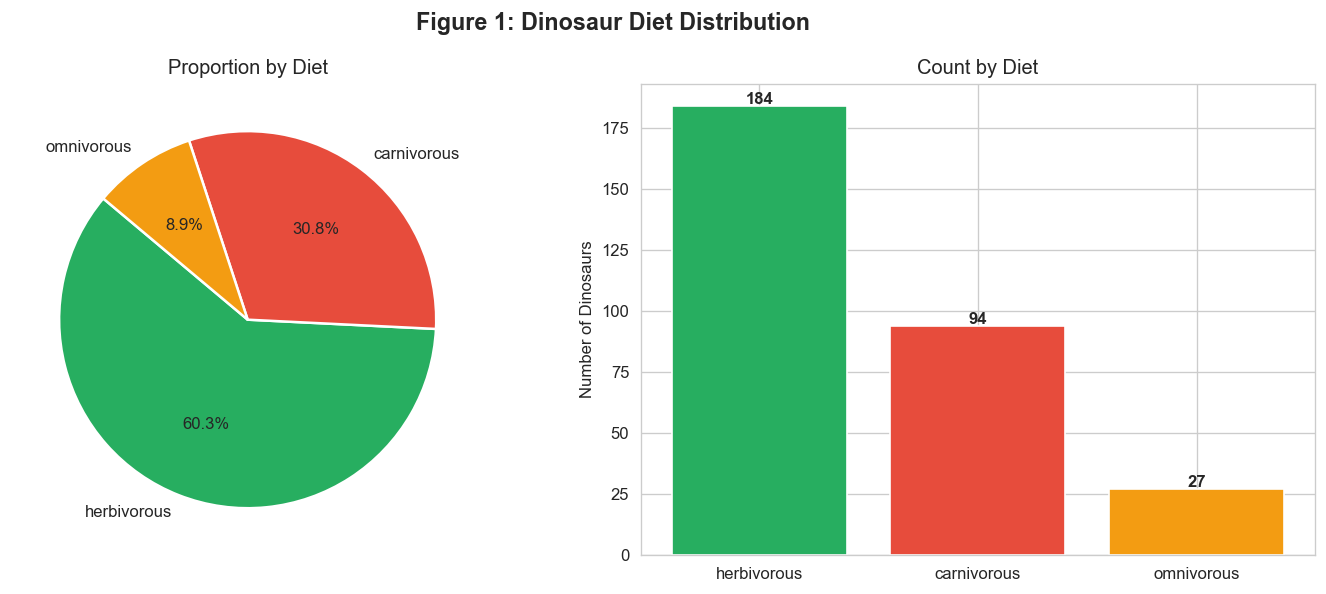

In [335]:

#  FIGURE 1 - DIET DISTRIBUTION (PIE CHART + BAR CHART)

print("Generating Figure 1: Diet Distribution")

# Create a figure with 2 subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Figure 1: Dinosaur Diet Distribution', fontsize=14, fontweight='bold')

# Count the number of dinosaurs in each diet category
diet_counts = df['diet'].value_counts()

# LEFT SUBPLOT: Pie chart showing proportions
axes[0].pie(diet_counts, 
            labels=diet_counts.index,  
            autopct='%1.1f%%',  
            colors=[palette[d] for d in diet_counts.index],  
            startangle=140, 
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})  
axes[0].set_title('Proportion by Diet')

# RIGHT SUBPLOT: Bar chart showing actual counts
axes[1].bar(diet_counts.index, diet_counts.values,
            color=[palette[d] for d in diet_counts.index], edgecolor='white')
axes[1].set_title('Count by Diet')
axes[1].set_ylabel('Number of Dinosaurs')

# Add count labels on top of each bar
for bar, val in zip(axes[1].patches, diet_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 str(val), ha='center', fontweight='bold')

plt.tight_layout()  
plt.show()  

---
## Section 5 — EDA: Body Length Analysis <a id='5'></a>

"Body size seems like a reasonable predictor of diet — after all, large carnivores and giant herbivores play very different roles in their ecosystems. In this section, we explore whether length_m tends to vary systematically between diet groups (using a boxplot) and across different types of dinosaurs (with a bar chart). If we see clear separation between the groups, that tells us length_m is worth including as a feature in our model."

Generating Figure 2: Body Length Analysis


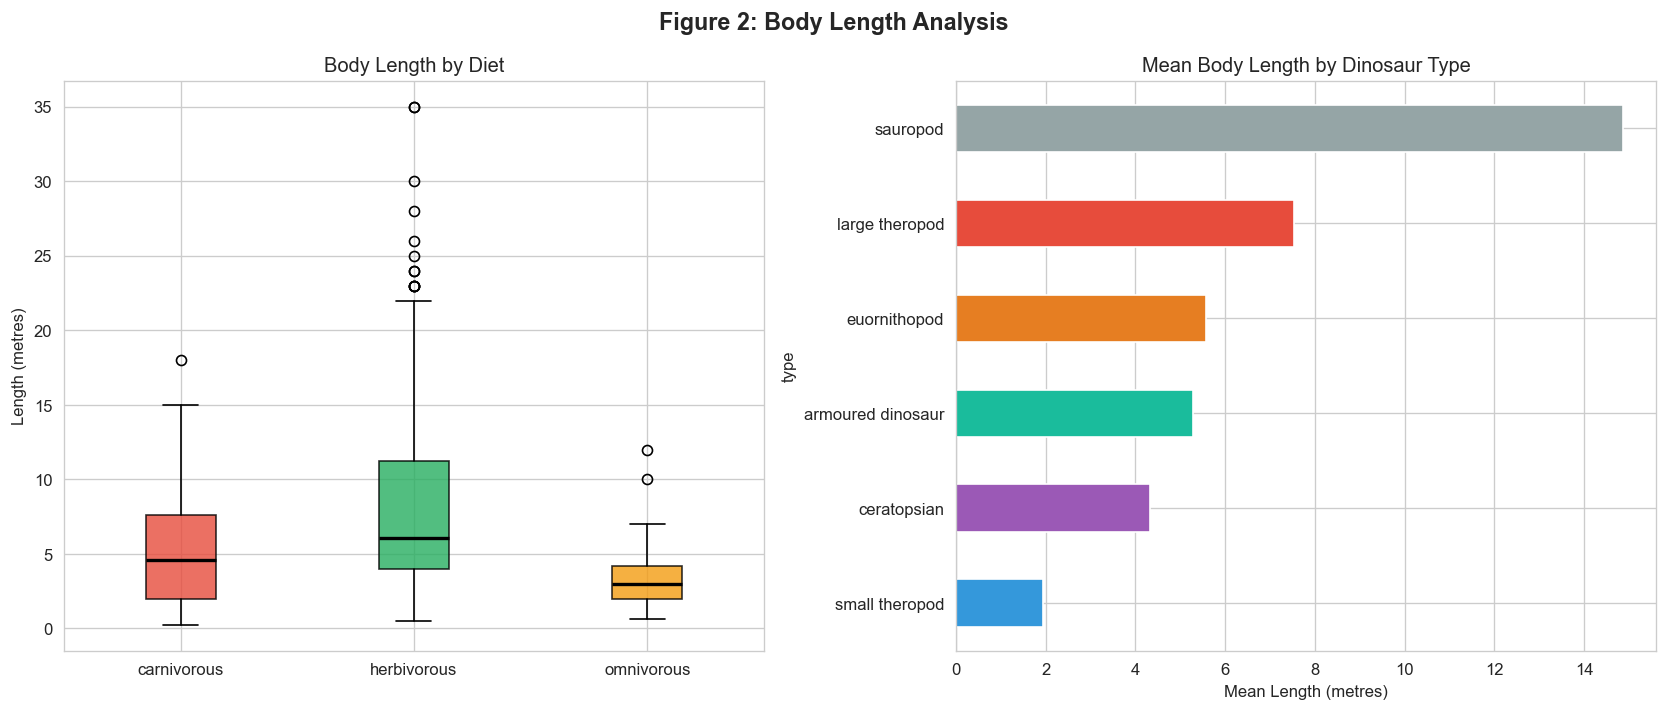

In [337]:

#  FIGURE 2 - BODY LENGTH ANALYSIS (BOXPLOT + BAR CHART)


print("Generating Figure 2: Body Length Analysis")

# Create a figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Figure 2: Body Length Analysis', fontsize=14, fontweight='bold')

diet_order = ['carnivorous', 'herbivorous', 'omnivorous']

# LEFT SUBPLOT: Boxplot showing length distribution by diet
# Boxplot shows median, quartiles, and outliers
bp = axes[0].boxplot([df[df['diet'] == d]['length_m'].dropna().values for d in diet_order],
                      labels=diet_order, patch_artist=True,
                      medianprops=dict(color='black', linewidth=2)) 
for patch, d in zip(bp['boxes'], diet_order):
    patch.set_facecolor(palette[d])  
    patch.set_alpha(0.8)  
axes[0].set_title('Body Length by Diet')
axes[0].set_ylabel('Length (metres)')

# RIGHT SUBPLOT: Mean length by dinosaur type (horizontal bar chart)
type_means = df.groupby('type')['length_m'].mean().sort_values()  
colors_bars = ['#3498DB', '#9B59B6', '#1ABC9C', '#E67E22', '#E74C3C', '#95A5A6', '#F39C12'][:len(type_means)]
type_means.plot(kind='barh', ax=axes[1], color=colors_bars)  
axes[1].set_title('Mean Body Length by Dinosaur Type')
axes[1].set_xlabel('Mean Length (metres)')

plt.tight_layout()
plt.show()

---
## Section 6 — EDA: Diet Across Geological Time <a id='6'></a>

"Dinosaurs roamed the Earth for about 165 million years, spanning three major eras. If their eating habits changed over that time, then era and sub_period could be useful clues for our model. The grouped bar chart shows the actual number of dinosaur species in each diet category per era. But because some eras have far more total fossils than others, we also include a stacked 100% chart — that normalises the data and shows the proportion of each diet within each era, making comparisons much fairer."

Generating Figure 3: Diet by Geological Era


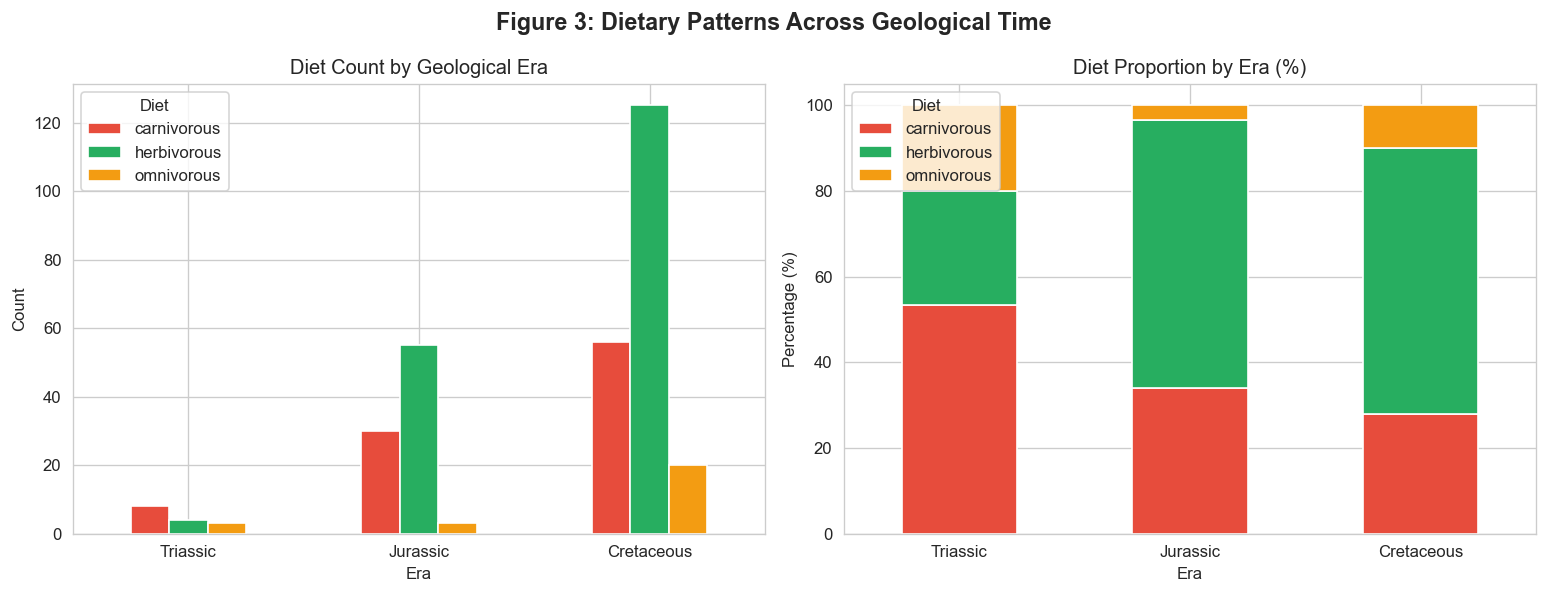

In [339]:
#  FIGURE 3 - DIET BY GEOLOGICAL ERA
# This cell shows how diet patterns changed across different time periods

print("Generating Figure 3: Diet by Geological Era")

# Create a figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Figure 3: Dietary Patterns Across Geological Time', fontsize=14, fontweight='bold')

# Create a cross-tabulation of era vs diet
# Group by era and diet, count occurrences, and fill missing with 0
era_diet = (df.groupby(['era', 'diet']).size().unstack(fill_value=0)
              .reindex(['Triassic', 'Jurassic', 'Cretaceous']))  

# LEFT SUBPLOT: Grouped bar chart showing count of each diet by era
era_diet.plot(kind='bar', ax=axes[0], 
              color=[palette.get(c, '#95A5A6') for c in era_diet.columns], 
              edgecolor='white')
axes[0].set_title('Diet Count by Geological Era')
axes[0].set_xlabel('Era')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)  
axes[0].legend(title='Diet')

# RIGHT SUBPLOT: Stacked bar chart showing percentage of each diet by era
era_pct = era_diet.div(era_diet.sum(axis=1), axis=0) * 100  
era_pct.plot(kind='bar', stacked=True, ax=axes[1],
             color=[palette.get(c, '#95A5A6') for c in era_pct.columns],
             edgecolor='white')
axes[1].set_title('Diet Proportion by Era (%)')
axes[1].set_xlabel('Era')
axes[1].set_ylabel('Percentage (%)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Diet')

plt.tight_layout()
plt.show()

---
## Section 7 — EDA: Geographic Distribution <a id='7'></a>

"Dinosaur fossils aren't evenly distributed around the world — partly because of where prehistoric landmasses were, but also because some regions have been studied much more intensively than others. This chart helps us see two things at once: which continents have the most fossil finds, and whether the balance of herbivores, carnivores, and omnivores differs from one place to another."

Generating Figure 4: Discoveries by Continent...


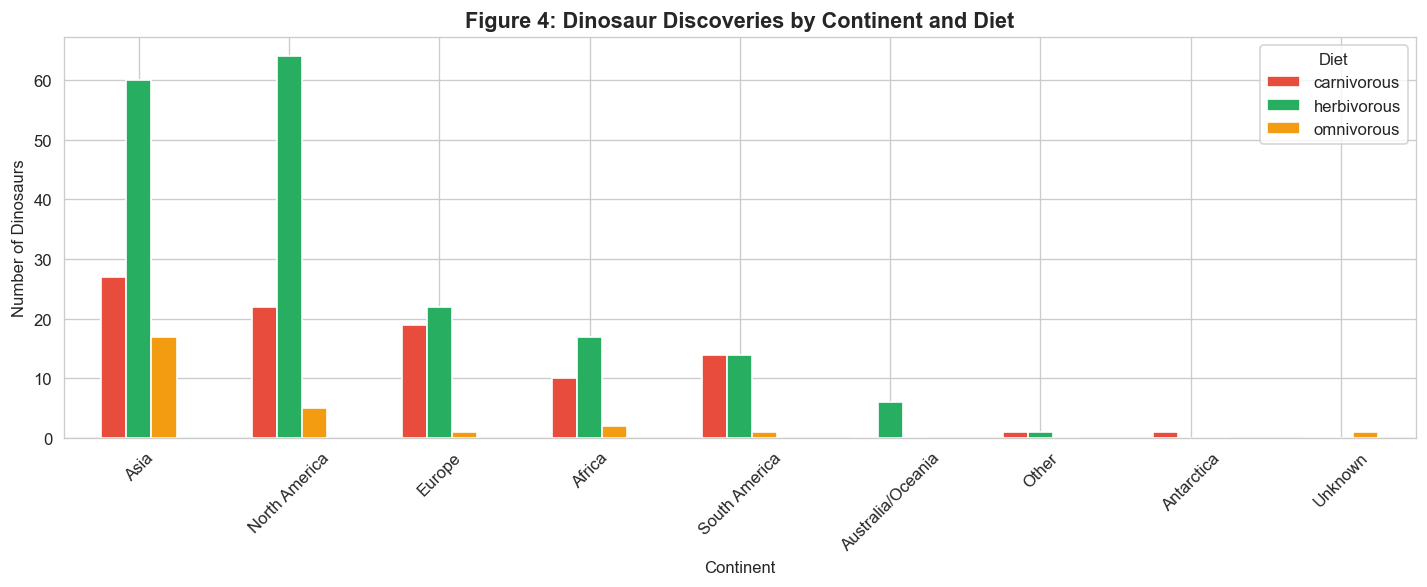

In [341]:

# FIGURE 4 - DISCOVERIES BY CONTINENT
# This cell shows the geographical distribution of dinosaur discoveries

print("Generating Figure 4: Discoveries by Continent...")

# Create a single figure
fig, ax = plt.subplots(figsize=(12, 5))

# Create cross-tabulation of continent vs diet
cont_diet = df.groupby(['continent', 'diet']).size().unstack(fill_value=0)

# Sort continents by total number of discoveries (largest to smallest)
cont_diet = cont_diet.reindex(cont_diet.sum(axis=1).sort_values(ascending=False).index)

# Create stacked bar chart showing diet composition by continent
cont_diet.plot(kind='bar', ax=ax, 
               color=[palette.get(c, '#95A5A6') for c in cont_diet.columns], 
               edgecolor='white')
ax.set_title('Figure 4: Dinosaur Discoveries by Continent and Diet', fontsize=13, fontweight='bold')
ax.set_xlabel('Continent')
ax.set_ylabel('Number of Dinosaurs')
ax.tick_params(axis='x', rotation=45)  
ax.legend(title='Diet')

plt.tight_layout()
plt.show()

---
## Section 8 — EDA: Diet by Dinosaur Type (Heatmap) <a id='8'></a>

"This heatmap shows the percentage of each diet category broken down by dinosaur type — for example, how many theropods were carnivores versus herbivores versus omnivores. If certain types like theropods or sauropods are strongly tied to a specific diet, that tells us type is likely to be a very useful feature for our classifier. We'll dig deeper into that idea when we look at feature importance later on."

 Generating Figure 5: Diet % by Type Heatmap...


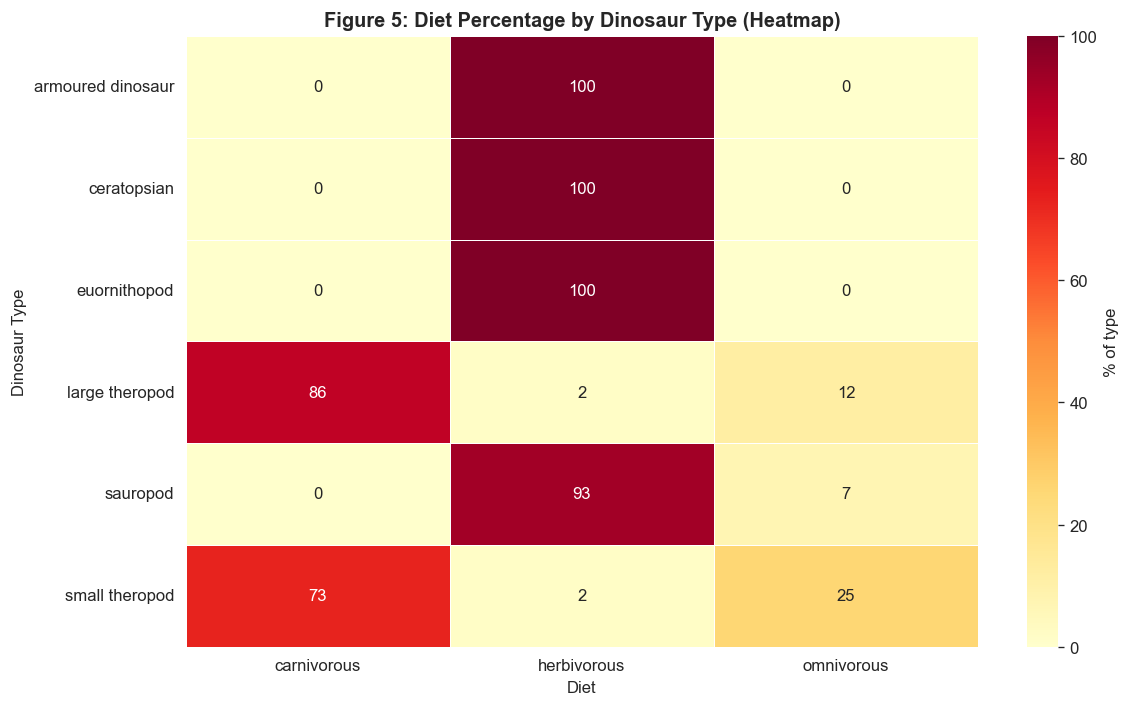

In [343]:

#  FIGURE 5 - HEATMAP OF DIET PERCENTAGE BY DINOSAUR TYPE

# This cell creates a heatmap showing what percentage of each dinosaur type belongs to each diet

print(" Generating Figure 5: Diet % by Type Heatmap...")

# Create cross-tabulation of dinosaur type vs diet
type_diet = df.groupby(['type', 'diet']).size().unstack(fill_value=0)

# Convert counts to percentages within each dinosaur type
type_diet_pct = type_diet.div(type_diet.sum(axis=1), axis=0) * 100

# Create heatmap
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(type_diet_pct, 
            annot=True,  
            fmt='.0f',   
            cmap='YlOrRd',  
            ax=ax, 
            linewidths=0.5,  
            cbar_kws={'label': '% of type'})  
ax.set_title('Figure 5: Diet Percentage by Dinosaur Type (Heatmap)', fontsize=12, fontweight='bold')
ax.set_xlabel('Diet')
ax.set_ylabel('Dinosaur Type')

plt.tight_layout()
plt.show()

---
## Section 9 — Model Preparation & Training (Random Forest) <a id='9'></a>

### Why Random Forest?
- Handles a mix of **categorical and numeric features** well.
- Robust to **outliers** and **missing values** (imputed above).
- Provides **feature importances** natively.
- Less prone to overfitting than single decision trees.

### Encoding
"Scikit-learn can't work directly with text — it needs numbers. So we use LabelEncoder to turn each categorical column into integers, like changing 'Jurassic' to 0 and 'Cretaceous' to 1. That's perfectly fine for tree-based models (like random forests or gradient boosting), because they don't assume that 0 is smaller than 1 in any meaningful way — they just treat the numbers as distinct category labels."

### Train/Test Split
An 80/20 stratified split preserves the class proportions in both sets, ensuring the test set is representative.

### Hyperparameters
| Parameter | Value | Reason |
|---|---|---|
| `n_estimators` | 200 | More trees → more stable predictions |
| `max_depth` | 8 | Limits tree depth to reduce overfitting |
| `class_weight` | `'balanced'` | Compensates for class imbalance observed in EDA |
| `random_state` | 42 | Ensures reproducibility |
| `n_jobs` | -1 | Use all available CPU cores for speed |

In [345]:

#  PREPARE DATA FOR RANDOM FOREST MODEL
# This cell encodes categorical variables and splits data for training/testing

print("Training Random Forest model...")

# Initialize LabelEncoders to convert text categories to numbers
le_type = LabelEncoder()  # For dinosaur type
le_era = LabelEncoder()   # For geological era
le_sub = LabelEncoder()   # For sub-period
le_cont = LabelEncoder()  
le_diet = LabelEncoder() 

# Create a copy of the dataframe for modeling
df_model = df.copy()

# Convert categorical text columns to numerical values
df_model['type_enc'] = le_type.fit_transform(df_model['type'])  # Type becomes 0,1,2,...
df_model['era_enc'] = le_era.fit_transform(df_model['era'])
df_model['sub_enc'] = le_sub.fit_transform(df_model['sub_period'])
df_model['cont_enc'] = le_cont.fit_transform(df_model['continent'])
df_model['diet_enc'] = le_diet.fit_transform(df_model['diet'])  # Target variable

# Remove rows with missing age values (cannot use them for training)
df_model.dropna(subset=['age_mya'], inplace=True)

# Define which columns will be used as features (inputs)
feature_cols = ['type_enc', 'era_enc', 'sub_enc', 'cont_enc', 'length_m', 'age_mya']
# Human-readable names for the features
feature_names = ['Dinosaur Type', 'Geological Era', 'Sub-Period', 'Continent', 'Body Length (m)', 'Age (Mya)']

# Separate features (X) and target (y)
X = df_model[feature_cols].values  # Input features
y = df_model['diet_enc'].values   


# stratify=y ensures the same proportion of diets in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Create and train Random Forest Classifier
rf = RandomForestClassifier(n_estimators=200,  # Number of trees in the forest
                            max_depth=8,       
                            class_weight='balanced',  
                            random_state=42,   
                            n_jobs=-1)        
rf.fit(X_train, y_train)

# Perform 5-fold cross-validation to evaluate model stability
cv_scores = cross_val_score(rf, X, y, cv=5, scoring='accuracy')

# Make predictions on test set
y_pred = rf.predict(X_test)

# Print model performance metrics
print(f"   Train: {len(X_train)} | Test: {len(X_test)}")
print(f"   5-Fold CV Accuracy: {cv_scores.mean():.3f} +/- {cv_scores.std():.3f}")
print(f"   Test Accuracy: {accuracy_score(y_test, y_pred):.3f}")

Training Random Forest model...
   Train: 241 | Test: 61
   5-Fold CV Accuracy: 0.854 +/- 0.049
   Test Accuracy: 0.885


---
## Section 10 — Model Evaluation: Confusion Matrix <a id='10'></a>

"Relying on accuracy alone can be deceptive when some categories are much rarer than others. That's why we use a confusion matrix — it shows us exactly which classes the model gets mixed up. We can see whether errors are spread fairly evenly across all diet types, or if they're mostly happening with the smallest group (in this case, omnivores). That kind of detail tells a much fuller story than a single accuracy number ever could."

 Generating Figure 6: Confusion Matrix...


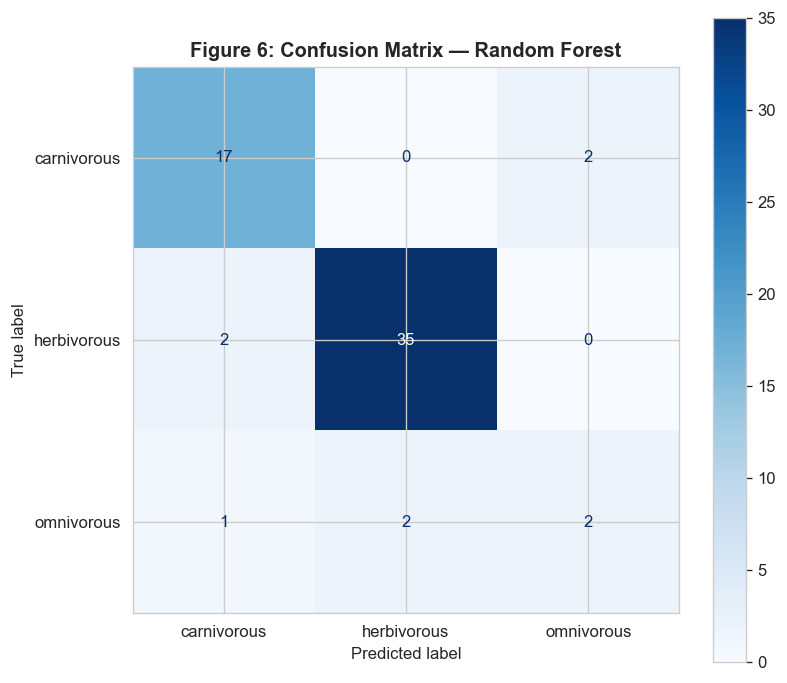

In [347]:

# FIGURE 6 - CONFUSION MATRIX

# This cell shows the confusion matrix to evaluate model performance

print(" Generating Figure 6: Confusion Matrix...")

# Create confusion matrix visualization
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), 
                       display_labels=le_diet.classes_).plot(ax=ax, 
                                                             colorbar=True, 
                                                             cmap='Blues')
ax.set_title('Figure 6: Confusion Matrix — Random Forest', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

---
## Section 11 — Model Interpretation: Feature Importances <a id='11'></a>

Random Forest computes **Mean Decrease in Impurity (MDI)** for each feature — how much each feature reduces uncertainty (Gini impurity) across all splits in all trees. Features with high importance are strong predictors of diet, confirming or challenging our EDA hypotheses.

Generating Figure 7: Feature Importances


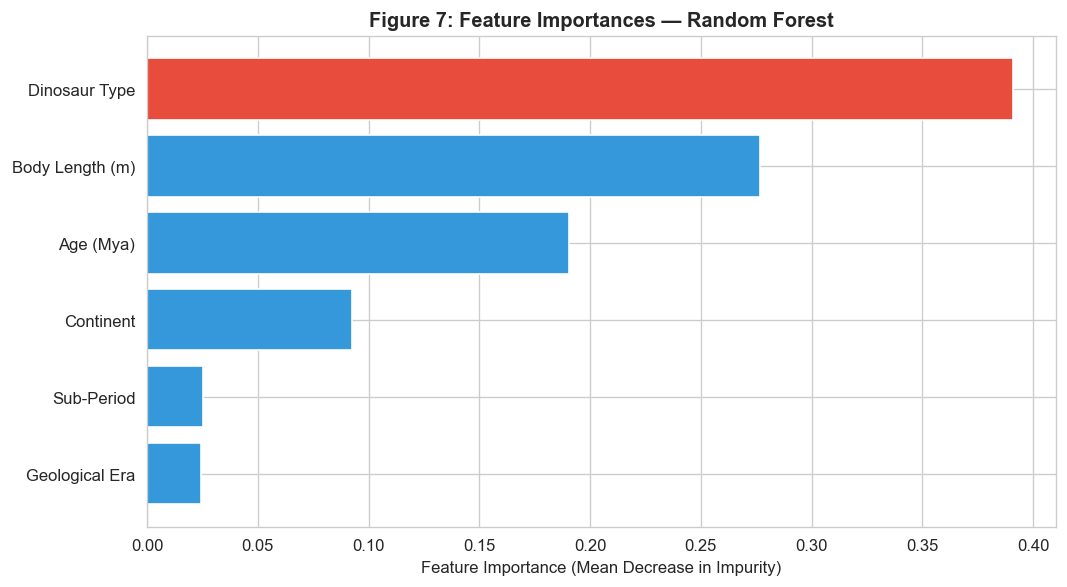

In [349]:

# FIGURE 7 - FEATURE IMPORTANCES
# This cell shows which features were most important for making predictions

print("Generating Figure 7: Feature Importances")

# Get feature importance scores from the trained model
importances = rf.feature_importances_

# Sort features by importance (ascending order for horizontal bar chart)
sorted_idx = np.argsort(importances)

# Create horizontal bar chart
fig, ax = plt.subplots(figsize=(9, 5))

# Color the most important feature red, others blue
colors = ['#E74C3C' if i == sorted_idx[-1] else '#3498DB' for i in sorted_idx]

ax.barh([feature_names[i] for i in sorted_idx], importances[sorted_idx], 
        color=colors, edgecolor='white')
ax.set_xlabel('Feature Importance (Mean Decrease in Impurity)')
ax.set_title('Figure 7: Feature Importances — Random Forest', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

---
## Section 12 — Model Stability: Cross-Validation by Fold <a id='12'></a>

A model that achieves high mean accuracy but with high variance across folds may be overfitting to certain subsets of the data. This plot displays accuracy for each individual fold against the mean, making variance immediately visible.

Generating Figure 8: CV Accuracy by Fold...


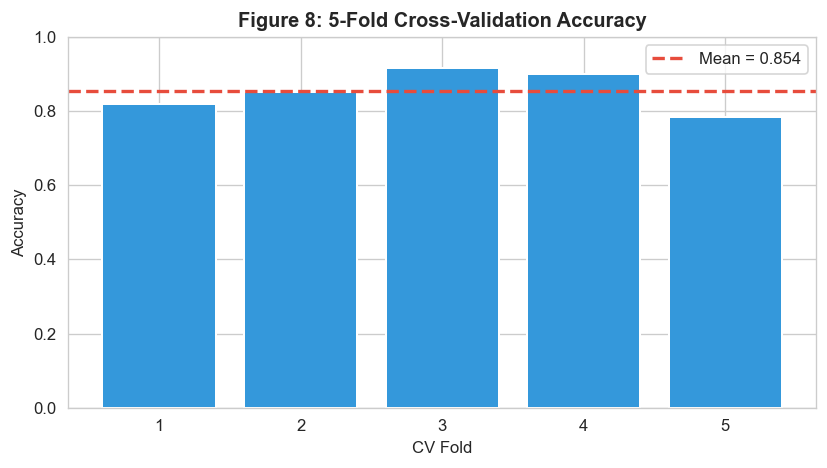

In [351]:

#  FIGURE 8 - CROSS-VALIDATION ACCURACY BY FOLD
# This cell shows the accuracy for each fold of cross-validation

print("Generating Figure 8: CV Accuracy by Fold...")

# Create bar chart of cross-validation scores
fig, ax = plt.subplots(figsize=(7, 4))

# Plot bars for each of the 5 folds
ax.bar(range(1, 6), cv_scores, color='#3498DB', edgecolor='white', linewidth=1.2)

# Add a horizontal line showing the mean accuracy across all folds
ax.axhline(cv_scores.mean(), color='#E74C3C', linestyle='--', linewidth=2, 
           label=f'Mean = {cv_scores.mean():.3f}')

ax.set_xlabel('CV Fold')
ax.set_ylabel('Accuracy')
ax.set_title('Figure 8: 5-Fold Cross-Validation Accuracy', fontweight='bold', fontsize=12)
ax.set_ylim(0, 1)  
ax.legend()

plt.tight_layout()
plt.show()

---
## Section 13 — Predicted Probability Analysis <a id='13'></a>

Hard predictions (class labels) tell us *what* the model predicted. **Predicted probabilities** tell us *how confident* it was. For each actual diet class, this chart shows the mean predicted probability for all three classes, revealing whether the model is confident when correct and appropriately uncertain otherwise.

Generating Figure 9: Predicted Probabilities...


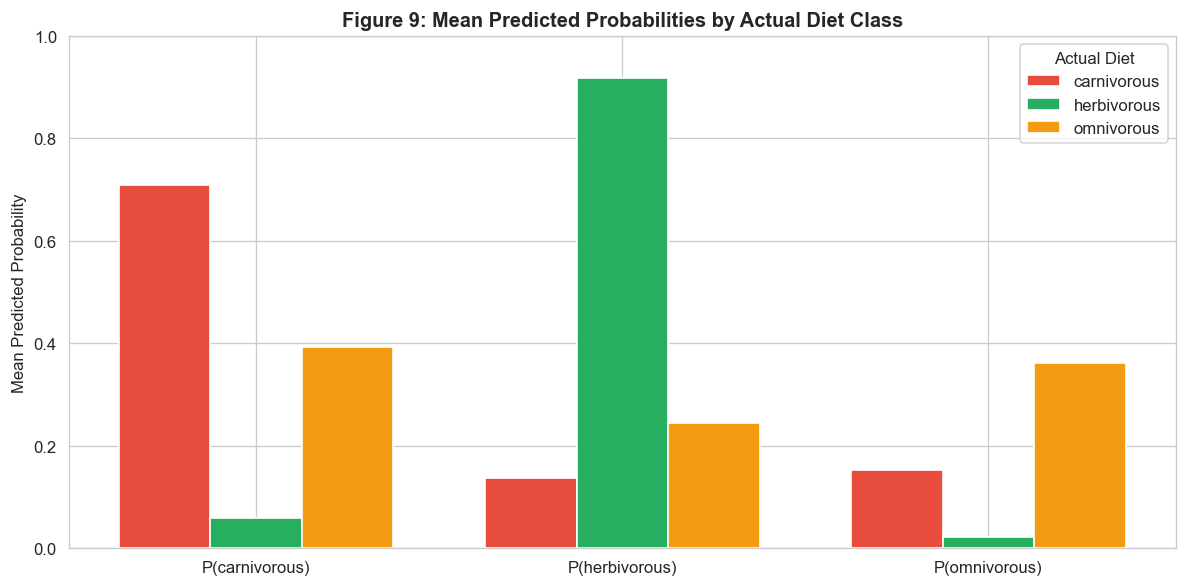

In [353]:

#  FIGURE 9 - PREDICTED PROBABILITIES BY ACTUAL CLASS

print("Generating Figure 9: Predicted Probabilities...")

# Get probability predictions for the test set
proba = rf.predict_proba(X_test)  

# Create dataframe with actual labels and predicted probabilities
sample_df = pd.DataFrame({
    'Actual': le_diet.inverse_transform(y_test), 
    'P(carnivorous)': proba[:, 0], 
    'P(herbivorous)': proba[:, 1],  
    'P(omnivorous)': proba[:, 2],   
})

# Calculate mean probability for each actual diet class
sample_mean = sample_df[['P(carnivorous)', 'P(herbivorous)', 'P(omnivorous)']].groupby(sample_df['Actual']).mean()

# Create grouped bar chart
x = np.arange(3)  
width = 0.25     

fig, ax = plt.subplots(figsize=(10, 5))

# Plot one group of bars for each actual diet class
for i, (label, row) in enumerate(sample_mean.iterrows()):
    ax.bar(x + i*width, row.values, width, 
           label=label, 
           color=palette.get(label, '#95A5A6'), 
           edgecolor='white')

# Configure the chart
ax.set_xticks(x + width) 
ax.set_xticklabels(['P(carnivorous)', 'P(herbivorous)', 'P(omnivorous)'])
ax.set_ylabel('Mean Predicted Probability')
ax.set_title('Figure 9: Mean Predicted Probabilities by Actual Diet Class', fontweight='bold', fontsize=12)
ax.legend(title='Actual Diet')
ax.set_ylim(0, 1)  

plt.tight_layout()
plt.show()

---
## Section 14 — Summary & Conclusions <a id='14'></a>

This section prints a consolidated report of all model metrics and a ranked list of feature importances, giving a single-cell overview of the project results.

In [355]:
# SUMMARY AND CONCLUSIONS

# This cell prints a final summary of the model's performance
print("="*55)
print("SUMMARY & CONCLUSIONS")
print("="*55)
# Print model accuracy metrics
print(f"5-Fold CV Accuracy : {cv_scores.mean():.3f} +/- {cv_scores.std():.3f}")
print(f"Test Set Accuracy  : {accuracy_score(y_test, y_pred):.3f}")

# Print feature importance rankings
print("\nTop Feature Importances:")
for i in sorted_idx[::-1]:  
    print(f"  {feature_names[i]:25s}: {importances[i]:.4f}")

# Print detailed classification report (precision, recall, F1-score)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le_diet.classes_))
print("="*55)
print(" Analysis completed All The figures displayed above for my report.")

SUMMARY & CONCLUSIONS
5-Fold CV Accuracy : 0.854 +/- 0.049
Test Set Accuracy  : 0.885

Top Feature Importances:
  Dinosaur Type            : 0.3908
  Body Length (m)          : 0.2765
  Age (Mya)                : 0.1903
  Continent                : 0.0927
  Sub-Period               : 0.0252
  Geological Era           : 0.0245

Classification Report:
              precision    recall  f1-score   support

 carnivorous       0.85      0.89      0.87        19
 herbivorous       0.95      0.95      0.95        37
  omnivorous       0.50      0.40      0.44         5

    accuracy                           0.89        61
   macro avg       0.77      0.75      0.75        61
weighted avg       0.88      0.89      0.88        61

 Analysis completed All The figures displayed above for my report.
